# Introduction to Exploratory Data Analysis (EDA) using `pandas` (Tutorial)

This notebook is used as a tutorial version of the `04_intro_to_pandas_eda.ipynb` notebook, which contains the complete version of this notebook. Please note that the original version of this notebook contains more plot examples that are not convered in this tutorial version. The data for this exercise is borrowed from [here](https://www.kaggle.com/leonardopena/top50spotify2019).

### 1. Read data

In [17]:
import pandas as pd

df = pd.read_csv("top50.csv", encoding='ISO-8859-2')

`pandas.read_csv()` documentation: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html

_Python encoding: https://docs.python.org/3/library/codecs.html#standard-encodings_

In [7]:
df.shape

(50, 14)

In [9]:
# view data
df.head()


,Unnamed: 0,Track.Name,Artist.Name,Genre,Beats.Per.Minute,Energy,Danceability,Loudness..dB..,Liveness,Valence.,Length.,Acousticness..,Speechiness.,Popularity
0,1,Seńorita,Shawn Mendes,canadian pop,117,55,76,-6,8,75,191,4,3,79
1,2,China,Anuel AA,reggaeton flow,105,81,79,-4,8,61,302,8,9,92
2,3,boyfriend (with Social House),Ariana Grande,dance pop,190,80,40,-4,16,70,186,12,46,85
3,4,Beautiful People (feat. Khalid),Ed Sheeran,pop,93,65,64,-8,8,55,198,12,19,86
4,5,Goodbyes (Feat. Young Thug),Post Malone,dfw rap,150,65,58,-4,11,18,175,45,7,94


Display some basic information about this data frame.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        50 non-null     int64 
 1   Track.Name        50 non-null     object
 2   Artist.Name       50 non-null     object
 3   Genre             50 non-null     object
 4   Beats.Per.Minute  50 non-null     int64 
 5   Energy            50 non-null     int64 
 6   Danceability      50 non-null     int64 
 7   Loudness..dB..    50 non-null     int64 
 8   Liveness          50 non-null     int64 
 9   Valence.          50 non-null     int64 
 10  Length.           50 non-null     int64 
 11  Acousticness..    50 non-null     int64 
 12  Speechiness.      50 non-null     int64 
 13  Popularity        50 non-null     int64 
dtypes: int64(11), object(3)
memory usage: 5.6+ KB


You can also use `df.dtypes` to view data types for each column.

View column names.

In [19]:
df.columns

Index(['Unnamed: 0', 'Track.Name', 'Artist.Name', 'Genre', 'Beats.Per.Minute',
       'Energy', 'Danceability', 'Loudness..dB..', 'Liveness', 'Valence.',
       'Length.', 'Acousticness..', 'Speechiness.', 'Popularity'],
      dtype='object')

### Drop a column

In [25]:
df = df.drop(df.columns[0],axis=1)

### Modify column names

View column names.

In [27]:
df.columns

Index(['Track.Name', 'Artist.Name', 'Genre', 'Beats.Per.Minute', 'Energy',
       'Danceability', 'Loudness..dB..', 'Liveness', 'Valence.', 'Length.',
       'Acousticness..', 'Speechiness.', 'Popularity'],
      dtype='object')

Convert the column-names array into a string object.

In [29]:
df.columns.str

Example: Convert all column names into uppercase.

In [35]:
df.columns = df.columns.str.upper()

Remove dots from column names.

In [43]:
df.columns = df.columns.str.replace('.','', regex = False)

Save the results into the data frame.

In [45]:
df.columns

Index(['TRACKNAME', 'ARTISTNAME', 'GENRE', 'BEATSPERMINUTE', 'ENERGY',
       'DANCEABILITY', 'LOUDNESSDB', 'LIVENESS', 'VALENCE', 'LENGTH',
       'ACOUSTICNESS', 'SPEECHINESS', 'POPULARITY'],
      dtype='object')

### Correlations

Plot the correlation matrix.

In [48]:
# import necessary packages
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
# create a heat map
corr_matrix = df.corr(numeric_only=True)
corr_matrix


,BEATSPERMINUTE,ENERGY,DANCEABILITY,LOUDNESSDB,LIVENESS,VALENCE,LENGTH,ACOUSTICNESS,SPEECHINESS,POPULARITY
BEATSPERMINUTE,1.000000,0.043756,-0.094183,0.017016,-0.167286,-0.011586,-0.139288,-0.031450,0.557052,0.196097
ENERGY,0.043756,1.000000,0.018254,0.670794,0.162768,0.438820,0.224677,-0.339892,-0.089860,-0.080295
DANCEABILITY,-0.094183,0.018254,1.000000,0.016255,-0.149636,0.172829,-0.000185,-0.098165,-0.103472,-0.071413
LOUDNESSDB,0.017016,0.670794,0.016255,1.000000,0.258652,0.237614,0.219219,-0.138300,-0.272213,-0.043085
LIVENESS,-0.167286,0.162768,-0.149636,0.258652,1.000000,0.016123,0.131782,0.021328,-0.125286,0.092564
VALENCE,-0.011586,0.438820,0.172829,0.237614,0.016123,1.000000,-0.017782,-0.052323,-0.053242,-0.317752
LENGTH,-0.139288,0.224677,-0.000185,0.219219,0.131782,-0.017782,1.000000,-0.076293,0.046755,-0.087639
ACOUSTICNESS,-0.031450,-0.339892,-0.098165,-0.138300,0.021328,-0.052323,-0.076293,1.000000,0.008293,-0.034684
SPEECHINESS,0.557052,-0.089860,-0.103472,-0.272213,-0.125286,-0.053242,0.046755,0.008293,1.000000,0.238553
POPULARITY,0.196097,-0.080295,-0.071413,-0.043085,0.092564,-0.317752,-0.087639,-0.034684,0.238553,1.000000


Increase the figure size.

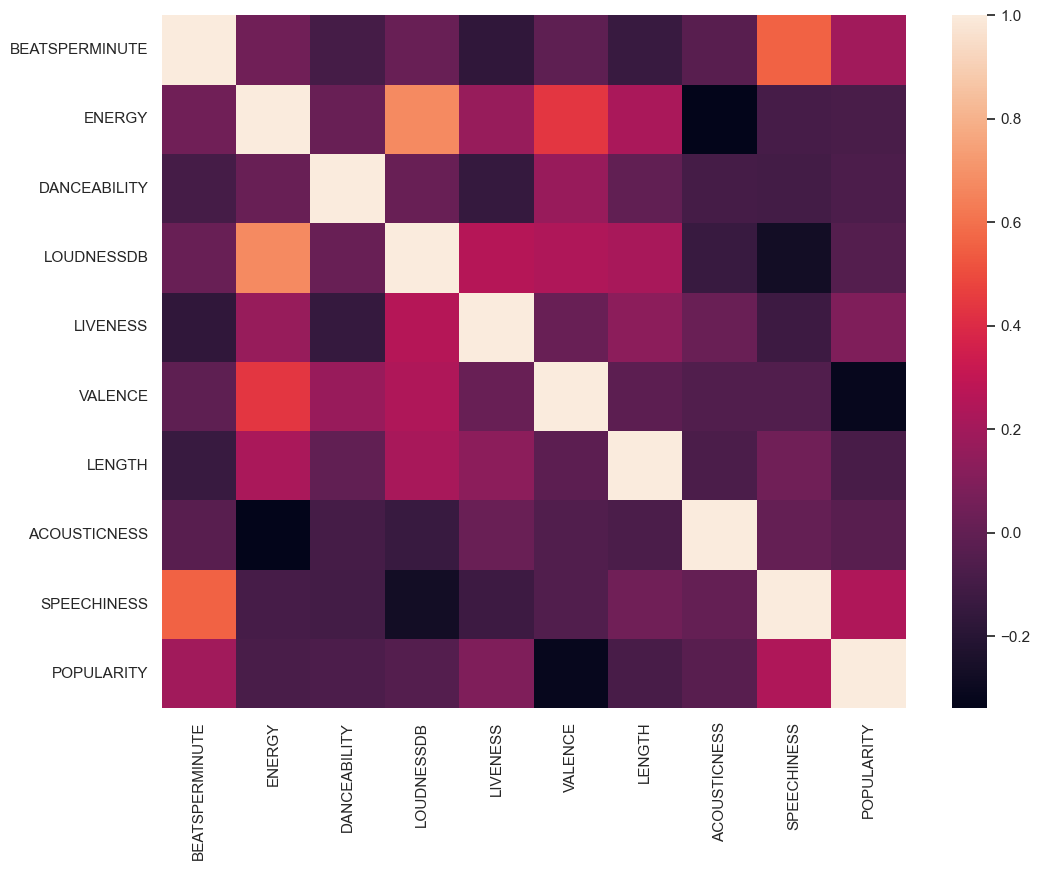

In [60]:
# set figure size


# create a heat map
sns.set_theme(style='white')

plt.figure(figsize=(12,9))

sns.heatmap(corr_matrix);

### Distributions

View summary statistics.

In [64]:
df.describe()

,count,mean,std,min,25%,50%,75%,max
BEATSPERMINUTE,50.0,120.06,30.898392,85.0,96.00,104.5,137.50,190.0
ENERGY,50.0,64.06,14.231913,32.0,55.25,66.5,74.75,88.0
DANCEABILITY,50.0,71.38,11.929880,29.0,67.00,73.5,79.75,90.0
LOUDNESSDB,50.0,-5.66,2.056448,-11.0,-6.75,-6.0,-4.00,-2.0
LIVENESS,50.0,14.66,11.118306,5.0,8.00,11.0,15.75,58.0
VALENCE,50.0,54.60,22.336024,10.0,38.25,55.5,69.50,95.0
LENGTH,50.0,200.96,39.143879,115.0,176.75,198.0,217.50,309.0
ACOUSTICNESS,50.0,22.16,18.995553,1.0,8.25,15.0,33.75,75.0
SPEECHINESS,50.0,12.48,11.161596,3.0,5.00,7.0,15.00,46.0
POPULARITY,50.0,87.50,4.491489,70.0,86.00,88.0,90.75,95.0


_`pandas.DataFrame.describe` documentation: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.describe.html_

Transpose the summary statistics for better visibility.

In [68]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BEATSPERMINUTE,50.0,120.06,30.898392,85.0,96.00,104.5,137.50,190.0
ENERGY,50.0,64.06,14.231913,32.0,55.25,66.5,74.75,88.0
DANCEABILITY,50.0,71.38,11.929880,29.0,67.00,73.5,79.75,90.0
LOUDNESSDB,50.0,-5.66,2.056448,-11.0,-6.75,-6.0,-4.00,-2.0
LIVENESS,50.0,14.66,11.118306,5.0,8.00,11.0,15.75,58.0
VALENCE,50.0,54.60,22.336024,10.0,38.25,55.5,69.50,95.0
LENGTH,50.0,200.96,39.143879,115.0,176.75,198.0,217.50,309.0
ACOUSTICNESS,50.0,22.16,18.995553,1.0,8.25,15.0,33.75,75.0
SPEECHINESS,50.0,12.48,11.161596,3.0,5.00,7.0,15.00,46.0
POPULARITY,50.0,87.50,4.491489,70.0,86.00,88.0,90.75,95.0


Export the summary statistics.

In [70]:
df.describe().T.to_csv('df_summary_stats.csv')

### Histograms

Plot a histogram for one variable.

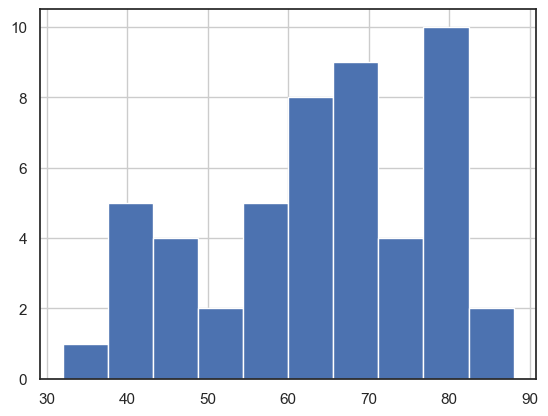

In [74]:
df['ENERGY'].hist();

_`pandas.DataFrame.hist` documentation: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.hist.html_

Plot histograms for multiple variables.

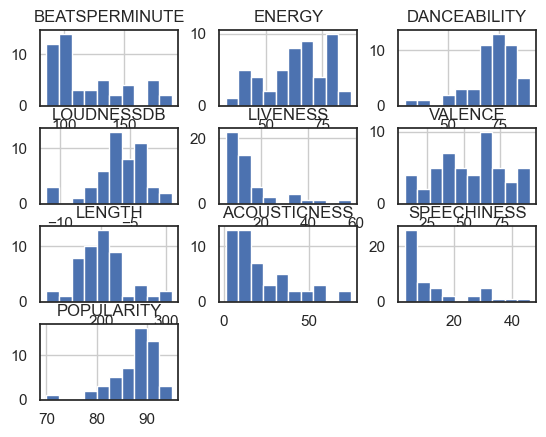

In [80]:
df.hist();

Change the bin size.

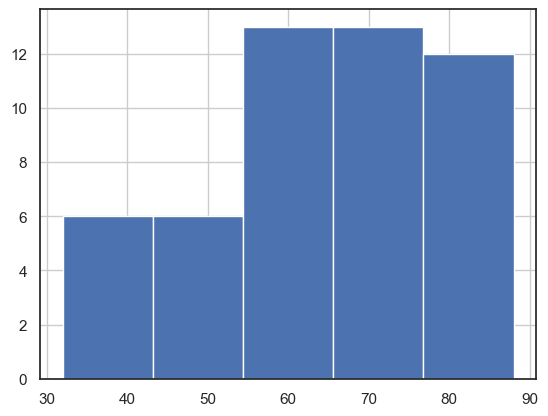

In [76]:
df['ENERGY'].hist(bins=5);

#### Format plots.

Define 10 subplots and arrange them into 5 rows and 2 columns.

View the axes component.

Iterate through the axes.

Iterate thru the column names in the data frame.

Isolate numeric columns.

A better way to isolate numeric columns is by using `df.dtypes`.

Check How many numeric columns we have.

Plot historgams for all numeric columns.

Increase the subplot figure sizes, improve the plot layout, and remove gridlines.

Use a color palette.

_Seabron Documentation on 'Choosing color palettes': https://seaborn.pydata.org/tutorial/color_palettes.html_

Apply this color palette to the histograms, and export the plot.

### Box plots

Check the distribution of `Genre`.

In [88]:
df.GENRE.value_counts()

GENRE
dance pop           8
pop                 7
latin               5
canadian hip hop    3
edm                 3
reggaeton           2
reggaeton flow      2
panamanian pop      2
canadian pop        2
electropop          2
country rap         2
dfw rap             2
brostep             2
trap music          1
escape room         1
pop house           1
australian pop      1
atl hip hop         1
big room            1
boy band            1
r&b en espanol      1
Name: count, dtype: int64

<Axes: xlabel='GENRE', ylabel='ENERGY'>

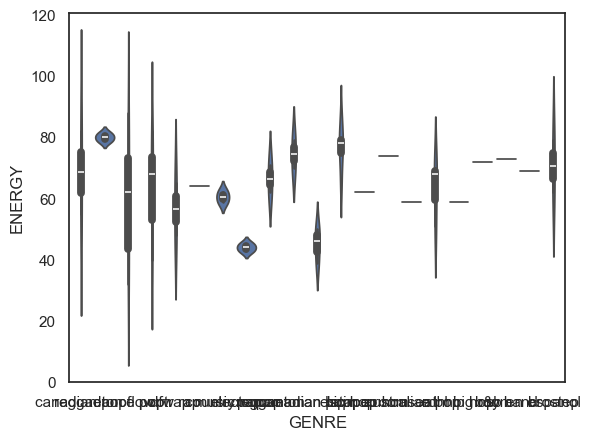

In [90]:
sns.violinplot(x='GENRE', y='ENERGY', data=df)

Combine similar generes to reduce cardinality.

In [94]:
import numpy as np

In [98]:
df['genre_grouped'] = np.where(df.GENRE.str.contains('pop'), 'POP', 
                               np.where(df.GENRE.str.contains('hip hop'), 'HIP HOP',
                                        np.where(df.GENRE.str.contains('rap'), 'RAP', 'OTHER')))



View data to ensure the mapping was done correctly.

In [100]:
df.genre_grouped.value_counts(normalize=True)

genre_grouped
POP        0.46
OTHER      0.36
RAP        0.10
HIP HOP    0.08
Name: proportion, dtype: float64

Plot the new genere column created above.

In [106]:
sns.__version__

'0.13.2'

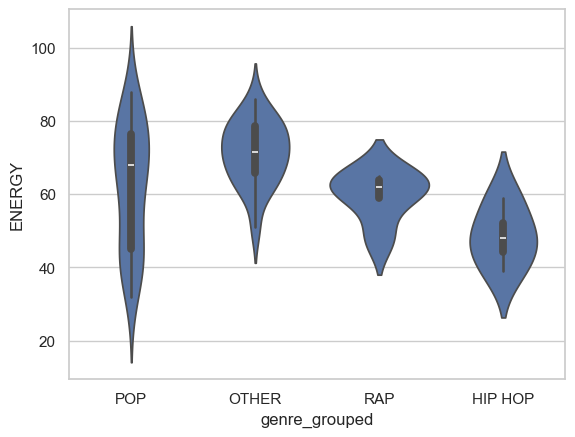

In [104]:
sns.set_theme(style='whitegrid')
sns.violinplot(x='genre_grouped', y='ENERGY', data=df);

Box plot.

Add axes labels.

Change plot layout to add gridlines.

### Scatter plot

Plot loudness versus energy.

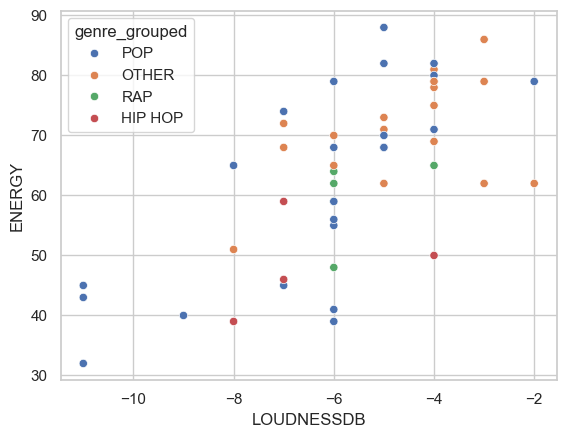

In [112]:
sns.scatterplot(x='LOUDNESSDB', y='ENERGY', data=df, hue='genre_grouped');

### Plotting pairwise data relationships using `seaborn`